In [1]:
pip install tiktoken matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import math
import torch
from datasets.preprocess import download_the_verdict
from datasets.dataloader import create_dataloader
from evaluation.loss import token_accuracy, cross_entropy_loss
from trainer.trainer import train_simple_model
from models.gpt2 import GPT
from configs.model import ModelConfig
from configs.training import TrainingConfig
import matplotlib.pyplot as plt

In [3]:
GPT2_SMALL = ModelConfig(
    emb_dim=32,
    n_layers=2,
    n_heads=4,
    activation="gelu",
    context_length=24
)

TRAIN_CONFIG = TrainingConfig(
    epochs=1,
    batch_size=2,
    stride=24,
    context_length=24
)


In [4]:
raw_text = download_the_verdict()
train_data = 0.9  ## train data to be 90%
len_train_data = math.floor(len(raw_text)* train_data)
train_data = raw_text[:len_train_data]
val_data = raw_text[len_train_data:] 


train_dataloader = create_dataloader(train_data, TRAIN_CONFIG)
val_dataloader = create_dataloader(val_data,TRAIN_CONFIG)

In [5]:
dataiter = iter(train_dataloader)
input_sample, target_sample = next(dataiter)
print(input_sample, target_sample)

tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,
           257,  7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438,
           568,   340,   373,   645],
        [ 1049,  5975,   284,   502,   284,  3285,   326,    11,   287,   262,
          6001,   286,   465, 13476,    11,   339,   550,  5710,   465, 12036,
            11,  6405,   257,  5527]]) tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,   257,
          7026, 15632,   438,  2016,   257,   922,  5891,  1576,   438,   568,
           340,   373,   645,  1049],
        [ 5975,   284,   502,   284,  3285,   326,    11,   287,   262,  6001,
           286,   465, 13476,    11,   339,   550,  5710,   465, 12036,    11,
          6405,   257,  5527, 27075]])


In [6]:
model = GPT(GPT2_SMALL)

In [ ]:
## calculating loss and accuracy on val dataset
def calc_loss_accuracy_loader(dataloader):
    with torch.no_grad():
        model.eval()
        val_loss= 0
        val_acc = 0
        for x,y in dataloader:
            output = model(x)
            loss = cross_entropy_loss(output, y)
            acc = token_accuracy(output,y)
            val_loss += loss.detach().numpy()
            val_acc += acc
        val_loss /= len(dataloader)
        acc /= len(dataloader)
        return val_loss ,acc
calc_loss_accuracy_loader(val_dataloader)

10.989379 tensor(0.)


(np.float32(10.989379), tensor(0.))

In [7]:
output = model(input_sample)
print(output.shape)

torch.Size([2, 24, 50257])


In [8]:
with torch.no_grad():
    output = model(input_sample)
    loss = cross_entropy_loss(output, target_sample)
    print(loss)


tensor(10.9901)


In [9]:
epoch = 3
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001)

In [10]:
torch.autograd.set_detect_anomaly(True)

In [29]:
train_history = {
    "train_loss":[],
    "train_accuracy":[],
    "val_loss":[],
    "val_accuracy":[]
}

In [30]:
def train_simple_model(epoch,model,dataloader,loss,optimizer):
    for _ in range(epoch):
        model.train()
        epoch_loss = 0
        for x,y in dataloader:
            optimizer.zero_grad()
            output = model(x)
            lossx = loss(output, y)
            lossx.backward()
            optimizer.step()
            epoch_loss += lossx.detach().numpy()
        train_avg_loss = epoch_loss / len(dataloader)
        train_history["train_loss"].append(train_avg_loss)
        val_loss , _ = calc_loss_accuracy_loader(val_dataloader)
        train_history["val_loss"].append(val_loss)

In [31]:
train_simple_model(epoch, model, train_dataloader, cross_entropy_loss, optimizer)

6.739853 tensor(0.4167)
6.671216 tensor(0.5208)
6.637347 tensor(0.4792)


In [33]:
print(train_history)

{'train_loss': [np.float32(6.568424), np.float32(6.1753926), np.float32(6.0321183)], 'train_accuracy': [], 'val_loss': [np.float32(6.739853), np.float32(6.671216), np.float32(6.637347)], 'val_accuracy': []}


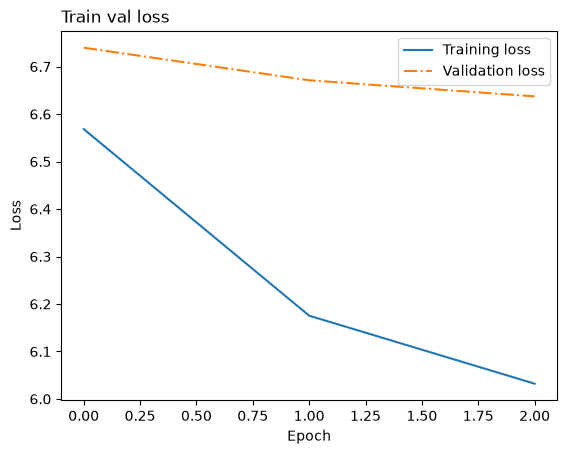

In [39]:
def plot_train_loss(loss):
    x_a = [i for i in range(len(loss)-1)]
    train_l = train_history["train_loss"]
    val_l = train_history["val_loss"]
    plt.title("Train val loss", loc="left")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(x_a, train_l, label="Training loss")
    plt.plot(x_a, val_l, linestyle="-." ,label="Validation loss")
    plt.legend(loc="upper right")
    plt.show()
plot_train_loss(train_history)

In [ ]:
for name, module in model.named_modules():
    print(name, module)

 GPT(
  (wte): Embedding(50257, 768)
  (pte): Embedding(264, 768)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MHA(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): MLP(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (mha): MHA(
        (W_q): Linear(in_features=768, out_features=768, bias=False)
        (W_k): Linear(in_features=768, out_features=768, bias=False)
        (W_v

In [41]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")



In [ ]:
def generate_sample_text(model, tokenizer, text, max_new_tokens):
    model.eval()

    tokens = torch.tensor([tokenizer.encode(text)])

    with torch.no_grad():
        for _ in range(max_new_tokens):

            logits = model(tokens)

            next_token = torch.argmax(
                logits[:, -1, :],
                dim=-1,
                keepdim=True
            )

            tokens = torch.cat(
                [tokens, next_token],
                dim=1
            )

    print(tokenizer.decode(tokens[0].tolist()))
generate_sample_text(model, tokenizer,"Every effort moves you",8)

tensor([[6109, 3626, 6100,  345,   13]])
tensor([[6109, 3626, 6100,  345,   13,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198,  198,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198,  198,  198,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198,  198,  198,  198,  198]])
tensor([[6109, 3626, 6100,  345,   13,  198,  198,  198,  198,  198,  198,  198]])
Every effort moves you.







